# Issue #2 – Dataset Validation


1) Loading cleaned dataset


In [9]:
import pandas as pd

df = pd.read_csv("C:/Users/Rudy2/capstone/unfc-capstone-traffic-forecasting/data/processed/svc_summary_clean.csv")

df.head()


,count_id,location_name,count_date_start,count_date_end,avg_daily_vol,avg_speed,avg_85th_percentile_speed,avg_95th_percentile_speed,avg_heavy_pct,congestion_target,congestion_level
0,3014976,Senlac Rd: Churchill Ave - Horsham Ave,2026-01-20,2026-01-22,7233.0,37.3,43.9,48.5,0.069,7233.0,Medium
1,3015033,Beachell St: Eglinton Ave E - Luella St,2026-01-20,2026-01-22,828.7,31.0,39.8,44.6,0.069,828.7,Low
2,3015251,Brookshire Blvd: Lanewood Cres - Blairwood Ter,2026-01-20,2026-01-22,341.7,29.3,38.4,44.0,0.069,341.7,Low
3,3015035,Dufferin St: Wenderly Dr - Claver Ave,2026-01-20,2026-01-22,29086.7,40.4,51.5,57.2,0.069,29086.7,Severe
4,3015036,Bremner Blvd: Olympic Park Trl - Rees St,2026-01-20,2026-01-22,6648.3,29.9,38.4,43.8,0.069,6648.3,Medium


2) Converting  date fields and  creating time features

In [ ]:


df["count_date_start"] = pd.to_datetime(df["count_date_start"], errors="coerce")
df["count_date_end"] = pd.to_datetime(df["count_date_end"], errors="coerce")

df["year"] = df["count_date_start"].dt.year
df["month"] = df["count_date_start"].dt.month




3) Temporal coverage

In [ ]:

df["year"].min(), df["year"].max()
df["year"].value_counts().sort_index()


year
1993    1836
1994    1062
1995     992
1996    1324
1997     321
1998    1294
1999    1406
2000     569
2001    1527
2002    1850
2003    2387
2004    2269
2005    2277
2006    2326
2007    1854
2008    1491
2009    1766
2010    2096
2011    2035
2012    2043
2013    1838
2014    1747
2015     632
2016     280
2017     749
2018     861
2019    1176
2020     431
2021    1071
2022     820
2023     831
2024     622
2025     676
2026      11
Name: count, dtype: int64

4) visual (counts per year)

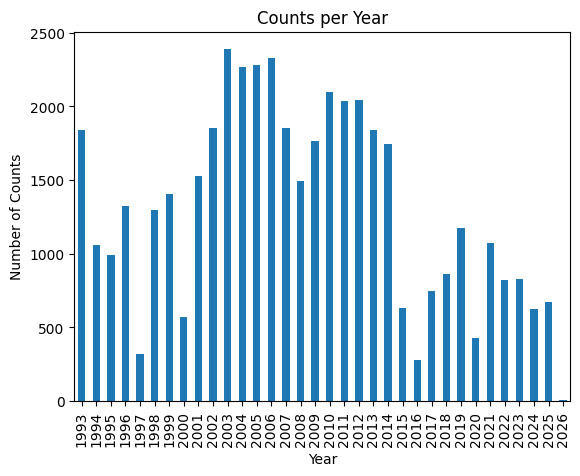

In [12]:
import matplotlib.pyplot as plt

df["year"].value_counts().sort_index().plot(kind="bar")
plt.title("Counts per Year")
plt.xlabel("Year")
plt.ylabel("Number of Counts")
plt.show()


5) Spatial Coverage (Locations)

In [ ]:

df["location_name"].nunique()
df.groupby("year")["location_name"].nunique().sort_index()


year
1993    1568
1994     933
1995     665
1996    1145
1997     130
1998     245
1999     134
2000     473
2001    1207
2002    1538
2003    2084
2004    2072
2005    1916
2006    1972
2007    1689
2008    1258
2009    1557
2010    1876
2011    1751
2012    1846
2013    1635
2014    1412
2015     591
2016     243
2017     693
2018     760
2019    1070
2020     416
2021     930
2022     645
2023     762
2024     601
2025     653
2026      11
Name: location_name, dtype: int64

6) visual ( unique locations per year)

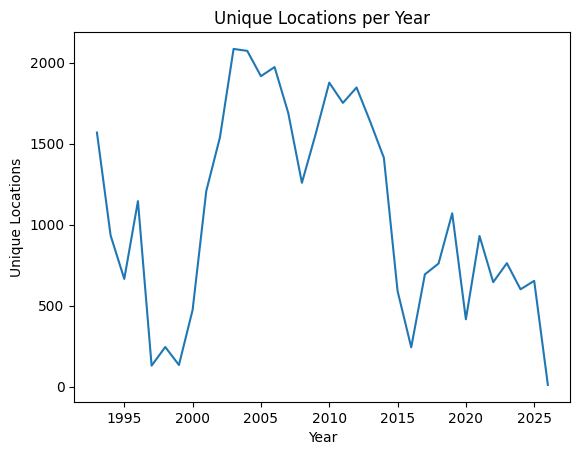

In [15]:
df.groupby("year")["location_name"].nunique().sort_index().plot(kind="line")
plt.title("Unique Locations per Year")
plt.xlabel("Year")
plt.ylabel("Unique Locations")
plt.show()


7) Completeness / Missing Values

In [ ]:

df.isna().sum().sort_values(ascending=False).head(15)


count_id                     0
location_name                0
count_date_start             0
count_date_end               0
avg_daily_vol                0
avg_speed                    0
avg_85th_percentile_speed    0
avg_95th_percentile_speed    0
avg_heavy_pct                0
congestion_target            0
congestion_level             0
year                         0
month                        0
dtype: int64

In [18]:
key_cols = ["avg_daily_vol", "avg_speed", 
            "avg_85th_percentile_speed", 
            "avg_95th_percentile_speed"]

df[key_cols].isna().mean().sort_values(ascending=False)



avg_daily_vol                0.0
avg_speed                    0.0
avg_85th_percentile_speed    0.0
avg_95th_percentile_speed    0.0
dtype: float64

8) count duration profile

In [33]:
df["count_date_start"] = pd.to_datetime(df["count_date_start"])
df["count_date_end"] = pd.to_datetime(df["count_date_end"])

df["count_duration_days"] = (
    df["count_date_end"] - df["count_date_start"]
).dt.days

df["count_duration_days"].value_counts().head(20)



count_duration_days
2     22463
0     16018
1      2655
6      1661
4       425
3       411
5       241
7       145
8       112
9        50
10       48
13       39
11       25
15       18
12       16
14       13
20       13
19       12
16       10
30       10
Name: count, dtype: int64